# Finding multiple minima — the repulsion family

`pounce.minimize` finds *one* local minimum. `pounce.find_minima` sweeps a
landscape for *many*. This notebook covers the **repulsion** methods, which
share one idea: **solve, record the minimum you found, then modify the
problem so the solver can't settle there again, and re-solve.**

| method | how it repels | reference |
|---|---|---|
| `flooding` | add a Gaussian bump to the objective at each found minimum | Ge, *Math. Program.* **46** (1990); Laio & Parrinello, *PNAS* **99** (2002) |
| `deflation` | add a singular `1/‖x−x*‖^p` pole penalty | Brown & Gearhart, *Numer. Math.* **16** (1971); Farrell et al., *SIAM J. Sci. Comput.* **37** (2015) |
| `tunneling` | between descents, seek an equal-height point away from known minima | Levy & Montalvo, *SIAM J. Sci. Stat. Comput.* **6** (1985) |

See `docs/src/find-minima.md` for the full method descriptions, references,
and guidance on choosing between them.

In [1]:
import os
os.environ["RUST_LOG"] = "off"  # quiet the harmless unconstrained-jacobian log
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pounce
print("pounce", pounce.__version__)

pounce 0.3.0


## The test landscape

The six-hump camel-back has six minima: two global (f = −1.0316) and four shallower ones.

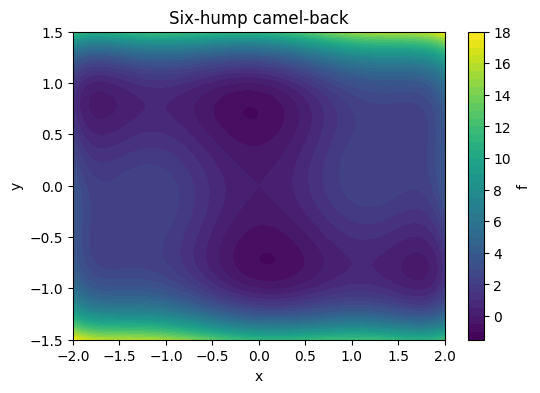

In [2]:
# Six-hump camel-back: 2 global minima (f=-1.0316) + 4 higher local minima.
def fun(z):
    x, y = z
    return (4 - 2.1*x**2 + x**4/3)*x**2 + x*y + (-4 + 4*y**2)*y**2

def jac(z):
    x, y = z
    return np.array([(8 - 8.4*x**2 + 2*x**4)*x + y, x + (-8 + 16*y**2)*y])

def hess(z):
    x, y = z
    return np.array([[8 - 25.2*x**2 + 10*x**4, 1.0], [1.0, -8 + 48*y**2]])

bounds = [(-2.0, 2.0), (-1.5, 1.5)]

def plot_landscape(minima=None, title=""):
    xs = np.linspace(-2, 2, 400); ys = np.linspace(-1.5, 1.5, 300)
    X, Y = np.meshgrid(xs, ys)
    Z = (4 - 2.1*X**2 + X**4/3)*X**2 + X*Y + (-4 + 4*Y**2)*Y**2
    plt.figure(figsize=(6, 4))
    plt.contourf(X, Y, Z, levels=40, cmap="viridis"); plt.colorbar(label="f")
    if minima is not None and len(minima):
        M = np.array(minima)
        plt.scatter(M[:, 0], M[:, 1], c="red", s=90, edgecolors="white",
                    zorder=5, label=f"{len(M)} minima")
        plt.legend(loc="upper right")
    plt.title(title); plt.xlabel("x"); plt.ylabel("y"); plt.show()

plot_landscape(title="Six-hump camel-back")

## Flooding

A Gaussian bump is dropped on each found minimum, lifting that basin so the next solve rolls out. Good for **broad enumeration** of all minima.

  f= -1.03163  at (-0.0898, +0.7127)
  f= -1.03163  at (+0.0898, -0.7127)
  f= -0.21546  at (+1.7036, -0.7961)
  f= -0.21546  at (-1.7036, +0.7961)
  f=  2.10425  at (-1.6071, -0.5687)
  f=  2.10425  at (+1.6071, +0.5687)

status=target_reached  found=6  solves=23


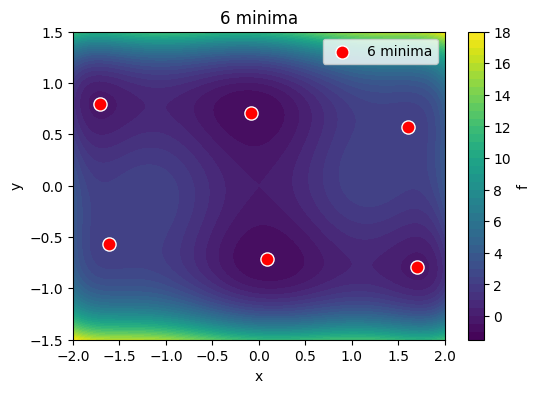

In [3]:
r = pounce.find_minima(fun, [0.5, 0.5], method="flooding", jac=jac, hess=hess,
                   bounds=bounds, n_minima=6, dedup=1e-3, seed=0,
                   options={"print_level": 0, "tol": 1e-9})
for x, f in zip(r.minima, r.values):
    print(f"  f={f:9.5f}  at ({x[0]:+.4f}, {x[1]:+.4f})")
print(f"\nstatus={r.status}  found={len(r)}  solves={r.n_solves}")
plot_landscape(r.minima, title=f"{len(r)} minima")

## Deflation

Instead of a finite local bump, a singular pole `1/‖x−x*‖^p` makes each found minimum infinitely costly. The pole reaches further than a Gaussian, so it is often the most solver-native repulsion for a Newton method.

  f= -1.03163  at (-0.0898, +0.7127)
  f= -1.03163  at (+0.0898, -0.7127)
  f= -0.21546  at (+1.7036, -0.7961)
  f= -0.21546  at (-1.7036, +0.7961)
  f=  2.10425  at (-1.6071, -0.5687)
  f=  2.10425  at (+1.6071, +0.5687)

status=target_reached  found=6  solves=23


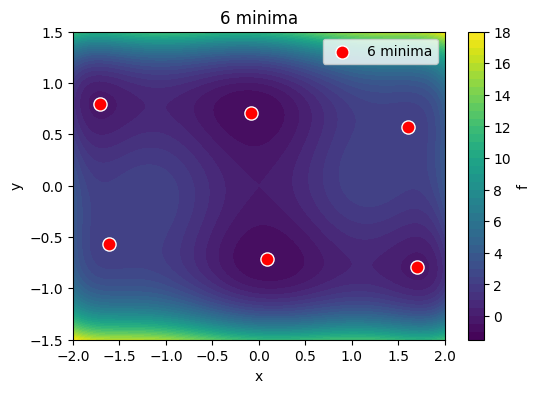

In [4]:
r = pounce.find_minima(fun, [0.5, 0.5], method="deflation", jac=jac, hess=hess,
                   bounds=bounds, n_minima=6, dedup=1e-3, seed=0,
                   options={"print_level": 0, "tol": 1e-9})
for x, f in zip(r.minima, r.values):
    print(f"  f={f:9.5f}  at ({x[0]:+.4f}, {x[1]:+.4f})")
print(f"\nstatus={r.status}  found={len(r)}  solves={r.n_solves}")
plot_landscape(r.minima, title=f"{len(r)} minima")

## Tunneling

Tunneling is **global-minimum oriented**: each step crosses to an equal-height point away from known minima and then descends, producing a *monotonically non-increasing* chain. It reliably finds the global basins rather than exhaustively enumerating every minimum.

  f= -1.03163  at (-0.0898, +0.7127)
  f= -1.03163  at (+0.0898, -0.7127)
  f= -0.21546  at (-1.7036, +0.7961)
  f= -0.21546  at (+1.7036, -0.7961)

status=converged  found=4  solves=57


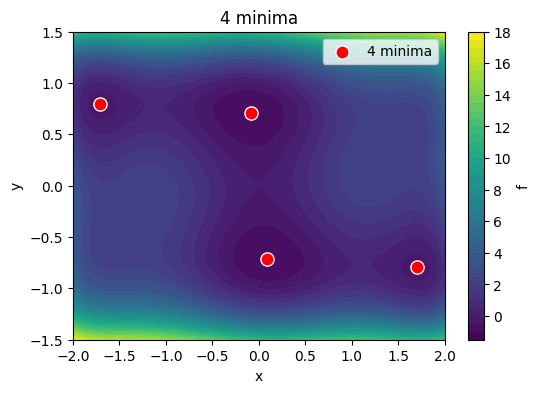

In [5]:
r = pounce.find_minima(fun, [0.5, 0.5], method="tunneling", jac=jac, hess=hess,
                   bounds=bounds, n_minima=6, max_solves=120, patience=25,
                   dedup=1e-3, seed=0, options={"print_level": 0, "tol": 1e-9})
for x, f in zip(r.minima, r.values):
    print(f"  f={f:9.5f}  at ({x[0]:+.4f}, {x[1]:+.4f})")
print(f"\nstatus={r.status}  found={len(r)}  solves={r.n_solves}")
plot_landscape(r.minima, title=f"{len(r)} minima")

## Choosing within the repulsion family

* **`flooding`** — broad enumeration; tune `sigma` (≈ spacing between minima)
  and `amplitude` (taller than a basin is deep). Smooth, local, analytic
  Hessian.
* **`deflation`** — also enumeration; the pole's longer reach can clear a
  basin a Gaussian would miss. Most natural for a Newton/IPM solver.
* **`tunneling`** — when you want the **global** minimum and a descending
  trail to it, not every minimum.

All three pass bounds and constraints straight through (they only touch the
objective). See `docs/src/find-minima.md` for cross-family guidance.